# Customer Priority Scoring

## Objective

The objective of this notebook is to develop a business-oriented customer prioritization framework for ISP customers.

Instead of relying solely on customer revenue, the proposed framework combines financial value with strategic business characteristics to create a Customer Priority Score.

The resulting score will support customer segmentation and business decision-making by identifying the customers who should receive the highest priority.

## 1. Load Clean Dataset

In [96]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

%matplotlib inline

In [97]:
df = pd.read_csv("../data/clean_isp_customers.csv")

print(df.shape)
print(df.columns.tolist())

(3000, 20)
['Customer_ID', 'Bandwidth_Mbps', 'Price_Per_Mbps', 'Monthly_Internet_Fee', 'Years_With_Company', 'Customer_Type', 'Company_Size', 'Strategic_Category', 'Strategic_Level', 'Has_VoIP', 'Monthly_VoIP_Fee', 'Has_Server', 'Server_Type', 'Monthly_Server_Fee', 'Support_Tickets_Last_Year', 'Downtime_Hours_Last_Year', 'Contract_Type', 'Total_Monthly_Revenue', 'Number_of_Services', 'High_Value']


## 2. Select Business Customers

### Objective

The priority scoring framework is designed for organizational customers.

Since the exploratory data analysis showed that Personal customers are not part of the high-value segment, this notebook focuses only on Business and Government customers.

In [98]:
df = df[df["Customer_Type"].isin(["Business", "Government"])].copy()

print(f"Number of customers: {len(df)}")
display(df["Customer_Type"].value_counts())

Number of customers: 1513


Customer_Type
Business      1251
Government     262
Name: count, dtype: int64

## 3. Selecting Priority Factors

### Objective

Based on the findings from the exploratory data analysis (Notebook 03), four customer characteristics were selected to construct the Customer Priority Score.

These features capture both the financial value and the business importance of each customer, providing a comprehensive basis for customer prioritization.

In [99]:
priority_factors = pd.DataFrame({
    "Feature": [
        "Total_Monthly_Revenue",
        "Strategic_Level",
        "Number_of_Services",
        "Company_Size"
    ],
    "Selection Basis": [
        "Revenue distribution analysis",
        "High-value customer analysis",
        "High-value customer analysis",
        "High-value customer analysis"
    ],
    "Business Role": [
        "Represents the customer's financial value",
        "Represents the customer's strategic importance",
        "Represents customer dependency on company services",
        "Represents long-term business potential"
    ]
})

priority_factors

,Feature,Selection Basis,Business Role
0,Total_Monthly_Revenue,Revenue distribution analysis,Represents the customer's financial value
1,Strategic_Level,High-value customer analysis,Represents the customer's strategic importance
2,Number_of_Services,High-value customer analysis,Represents customer dependency on company serv...
3,Company_Size,High-value customer analysis,Represents long-term business potential


### Observation

The selected features were chosen based on the findings of the exploratory data analysis.

Revenue represents the customer's direct financial contribution, while Strategic Level, Number of Services, and Company Size capture important business characteristics observed among high-value customers.

Together, these features provide a more comprehensive representation of customer priority than revenue alone.

## 4. Feature Scoring

### Objective

The selected features are measured using different units and scales.

Before combining them into a single Customer Priority Score, each feature is transformed into a standardized score ranging from 0 to 100.

This ensures that all features are comparable while preserving their relative importance.

### 4.1 Revenue Score

#### Objective

Revenue is the primary indicator of customer value.

To make revenue comparable with the remaining features, it is normalized to a scale between 0 and 100 using Min-Max Scaling.

In [100]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 100))

df["Revenue_Score"] = scaler.fit_transform(
    df[["Total_Monthly_Revenue"]]
)

In [101]:
df["Revenue_Score"].describe()

count    1513.000000
mean       25.554360
std        14.593750
min         0.000000
25%        15.725303
50%        25.164087
75%        34.820638
max       100.000000
Name: Revenue_Score, dtype: float64

### Observation

The revenue values have been successfully normalized to a common scale between 0 and 100 using Min-Max Scaling.

Customers with higher monthly revenue receive higher Revenue Scores while preserving the relative differences between customers. This standardized score will serve as the primary financial component of the Customer Priority Score.

### 4.2 Strategic Level Score

#### Objective

Strategic Level reflects the business importance of each customer.

Instead of assigning arbitrary scores, the Strategic Level Score is derived from the proportion of high-value customers observed at each strategic level in the exploratory data analysis.

This data-driven approach ensures that the assigned scores reflect actual customer characteristics rather than subjective assumptions.

In [102]:
strategic_score = (
    df.groupby("Strategic_Level")["High_Value"]
      .mean()
      .mul(100)
      .round(1)
      .sort_values()
)

strategic_score

Strategic_Level
1    26.0
2    43.8
3    63.6
Name: High_Value, dtype: float64

In [103]:
df["Strategic_Score"] = df["Strategic_Level"].map(strategic_score)

In [104]:
df[["Strategic_Level", "Strategic_Score"]].head()

,Strategic_Level,Strategic_Score
5,1,26.0
6,1,26.0
7,1,26.0
11,1,26.0
13,3,63.6


### Observation

The Strategic Level Score was calculated from the percentage of high-value customers within each strategic level.

Customers in higher strategic levels are more likely to belong to the high-value segment and therefore receive higher scores. This scoring approach is entirely data-driven and avoids manually assigning arbitrary values.

### 4.3 Number of Services Score

#### Objective

Customers using multiple services are generally more valuable because they rely on a broader range of the company's offerings.

To quantify this characteristic, the Number of Services Score is calculated using the observed proportion of high-value customers for each service count.

This data-driven approach rewards customers whose service usage patterns are more frequently associated with high-value customers.

In [105]:
services_score_map = (
    df.groupby("Number_of_Services")["High_Value"]
      .mean()
      .mul(100)
      .round(1)
      .sort_index()
)

services_score_map

Number_of_Services
1    27.5
2    35.6
3    63.2
Name: High_Value, dtype: float64

In [106]:
df["Services_Score"] = (
    df["Number_of_Services"]
      .map(services_score_map)
)

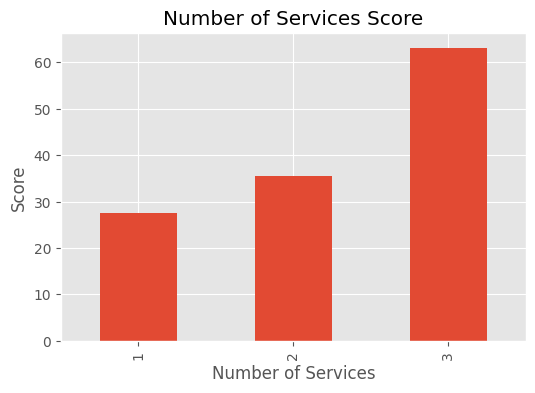

In [107]:
import matplotlib.pyplot as plt
services_score_map.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Number of Services Score")
plt.xlabel("Number of Services")
plt.ylabel("Score")

plt.show()

### Observation

The Number of Services Score was derived from the percentage of high-value customers associated with each service count.

Customers subscribing to a greater number of services tend to have a higher probability of being high-value customers and therefore receive higher scores.

### 4.4 Company Size Score

#### Objective

Company Size represents the long-term business potential of each customer.

The Company Size Score is calculated using the observed proportion of high-value customers within each company size category.

This approach ensures that larger business customers receive higher scores only if the data supports their association with high-value customers.

In [108]:
company_size_score_map = (
    df.groupby("Company_Size")["High_Value"]
      .mean()
      .mul(100)
      .round(1)
)

company_size_score_map

Company_Size
Large     56.8
Medium    26.2
Small     25.8
Name: High_Value, dtype: float64

In [109]:
df["Company_Size_Score"] = (
    df["Company_Size"]
      .map(company_size_score_map)
)

In [110]:
df[["Company_Size", "Company_Size_Score"]].head()

,Company_Size,Company_Size_Score
5,Medium,26.2
6,Small,25.8
7,Small,25.8
11,Small,25.8
13,Large,56.8


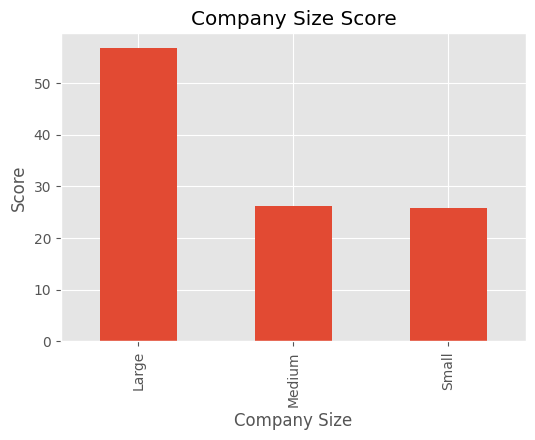

In [111]:
company_size_score_map.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Company Size Score")
plt.xlabel("Company Size")
plt.ylabel("Score")

plt.show()

### Observation

The Company Size Score was derived from the observed percentage of high-value customers within each company size category.

Company sizes with a greater concentration of high-value customers receive higher scores, ensuring that the scoring reflects real customer behavior rather than predefined assumptions.

## 5. Feature Weighting

### Objective

The four feature scores do not contribute equally to customer priority.

Revenue is considered the most important indicator because it directly reflects the customer's financial value. The remaining features capture strategic importance, service dependency, and long-term business potential.

Therefore, feature weights are assigned using a combination of business knowledge and insights obtained from the exploratory data analysis.

In [112]:
weights = {
    "Revenue_Score": 0.50,
    "Strategic_Score": 0.20,
    "Services_Score": 0.15,
    "Company_Size_Score": 0.15
}

weights

{'Revenue_Score': 0.5,
 'Strategic_Score': 0.2,
 'Services_Score': 0.15,
 'Company_Size_Score': 0.15}

### Observation

Revenue receives the highest weight because it directly measures the customer's financial contribution.

The remaining features receive lower weights as they provide complementary business information related to strategic importance, service adoption, and company characteristics.

Together, these weights balance financial performance with long-term business value.

## 6. Customer Priority Score

### Objective

The Customer Priority Score combines all standardized feature scores into a single business priority indicator.

Each feature contributes according to its assigned business weight, resulting in a final score between 0 and 100 that represents the overall importance of each customer.

In [113]:
df["Customer_Priority_Score"] = (
    df["Revenue_Score"] * weights["Revenue_Score"] +
    df["Strategic_Score"] * weights["Strategic_Score"] +
    df["Services_Score"] * weights["Services_Score"] +
    df["Company_Size_Score"] * weights["Company_Size_Score"]
)

In [114]:
df[[
    "Revenue_Score",
    "Strategic_Score",
    "Services_Score",
    "Company_Size_Score",
    "Customer_Priority_Score"
]].head()

,Revenue_Score,Strategic_Score,Services_Score,Company_Size_Score,Customer_Priority_Score
5,17.924412,26.0,27.5,26.2,22.217206
6,17.891611,26.0,35.6,25.8,23.355805
7,17.060441,26.0,35.6,25.8,22.940220
11,15.444751,26.0,27.5,25.8,20.917375
13,40.241369,63.6,27.5,56.8,45.485684


In [115]:
df.to_csv("../data/customer_priority_dataset.csv", index=False)

print("Customer priority dataset saved successfully.")

Customer priority dataset saved successfully.


In [116]:
df["Customer_Priority_Score"].describe()

count    1513.000000
mean       33.240032
std        11.969111
min        13.195000
25%        23.564321
50%        32.254816
75%        43.032980
max        75.365000
Name: Customer_Priority_Score, dtype: float64

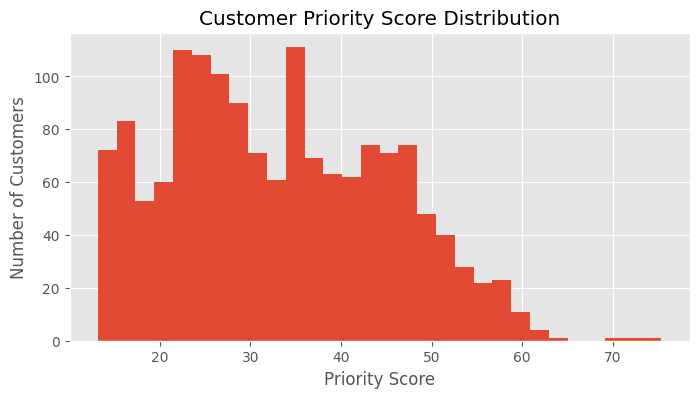

In [117]:
plt.figure(figsize=(8,4))

plt.hist(df["Customer_Priority_Score"], bins=30)

plt.title("Customer Priority Score Distribution")
plt.xlabel("Priority Score")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The Customer Priority Score combines financial and business-related characteristics into a single metric.

Customers with higher scores generate greater business value by combining strong financial contribution, strategic importance, service adoption, and company characteristics.

This score serves as the foundation for the customer segmentation performed in the next section.

# Conclusion

In this notebook, a data-driven Customer Priority Score was developed to quantify the overall business importance of each non-personal customer.

Four key features were selected based on the findings of the exploratory data analysis:
- Total Monthly Revenue
- Strategic Level
- Number of Services
- Company Size

Revenue was standardized using Min-Max Scaling, while the remaining features were scored according to the observed proportion of high-value customers in each category. The standardized scores were then combined using business-defined weights to produce a single Customer Priority Score.

The resulting score provides a continuous measure of customer priority rather than predefined customer categories. This allows the data to determine whether natural customer segments exist instead of imposing arbitrary thresholds.

The next notebook will analyze the distribution of the Customer Priority Score, identify the optimal number of customer segments using clustering techniques, and validate whether the resulting segments accurately represent meaningful customer groups.

In [119]:
print(df.columns.tolist())

['Customer_ID', 'Bandwidth_Mbps', 'Price_Per_Mbps', 'Monthly_Internet_Fee', 'Years_With_Company', 'Customer_Type', 'Company_Size', 'Strategic_Category', 'Strategic_Level', 'Has_VoIP', 'Monthly_VoIP_Fee', 'Has_Server', 'Server_Type', 'Monthly_Server_Fee', 'Support_Tickets_Last_Year', 'Downtime_Hours_Last_Year', 'Contract_Type', 'Total_Monthly_Revenue', 'Number_of_Services', 'High_Value', 'Revenue_Score', 'Strategic_Score', 'Services_Score', 'Company_Size_Score', 'Customer_Priority_Score']


In [120]:
df.to_csv("../data/customer_priority_dataset.csv", index=False)

In [121]:
test = pd.read_csv("../data/customer_priority_dataset.csv")

print(test.columns.tolist())

['Customer_ID', 'Bandwidth_Mbps', 'Price_Per_Mbps', 'Monthly_Internet_Fee', 'Years_With_Company', 'Customer_Type', 'Company_Size', 'Strategic_Category', 'Strategic_Level', 'Has_VoIP', 'Monthly_VoIP_Fee', 'Has_Server', 'Server_Type', 'Monthly_Server_Fee', 'Support_Tickets_Last_Year', 'Downtime_Hours_Last_Year', 'Contract_Type', 'Total_Monthly_Revenue', 'Number_of_Services', 'High_Value', 'Revenue_Score', 'Strategic_Score', 'Services_Score', 'Company_Size_Score', 'Customer_Priority_Score']
